In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

from numba import cuda
import math

Shape: (251, 201, 3)
dtype: uint8


(np.float64(-0.5), np.float64(200.5), np.float64(250.5), np.float64(-0.5))

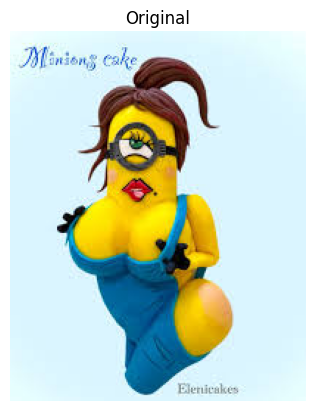

In [2]:
image = cv2.imread("img1.jpg", cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Shape:", image.shape)
print("dtype:", image.dtype)

plt.imshow(image)
plt.title("Original")
plt.axis("off")

In [3]:
height, width, channels = image.shape

threads_per_block = (16,16)

blocks_x = math.ceil(height / threads_per_block[0])
blocks_y = math.ceil(width / threads_per_block[1])

blocks_per_grid = (blocks_x, blocks_y)
d_image = cuda.to_device(image)

In [4]:
@cuda.jit
def negative_filter(img, output):

    row, col = cuda.grid(2)

    if row >= img.shape[0] or col >= img.shape[1]:
        return

    for c in range(3):
        output[row, col, c] = 255 - img[row, col, c]

(np.float64(-0.5), np.float64(200.5), np.float64(250.5), np.float64(-0.5))

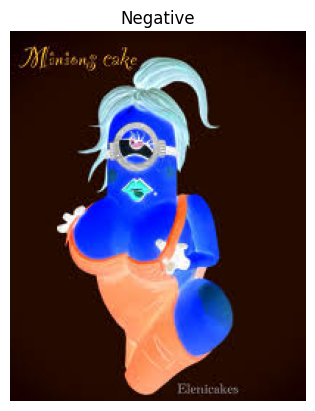

In [5]:
d_negative = cuda.device_array_like(image)

negative_filter[blocks_per_grid, threads_per_block](d_image, d_negative)

negative_img = d_negative.copy_to_host()

plt.imshow(negative_img)
plt.title("Negative")
plt.axis("off")

In [6]:
@cuda.jit
def blur_filter(img, output):

    row, col = cuda.grid(2)

    H = img.shape[0]
    W = img.shape[1]

    if row >= H or col >= W:
        return

    for c in range(3):

        acc = 0
        count = 0

        for dx in range(-1,2):
            for dy in range(-1,2):

                r = row + dx
                c2 = col + dy

                if 0 <= r < H and 0 <= c2 < W:
                    acc += img[r,c2,c]
                    count += 1

        output[row,col,c] = acc // count

(np.float64(-0.5), np.float64(200.5), np.float64(250.5), np.float64(-0.5))

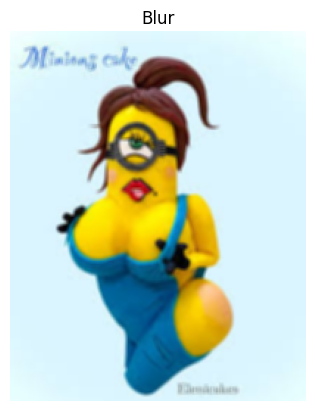

In [7]:
d_blur = cuda.device_array_like(image)

blur_filter[blocks_per_grid, threads_per_block](d_image, d_blur)

blur_img = d_blur.copy_to_host()

plt.imshow(blur_img)
plt.title("Blur")
plt.axis("off")

In [8]:
x_start = 100
y_start = 100

crop_w = 300
crop_h = 300

In [9]:
@cuda.jit
def crop_filter(img, output, x_start, y_start):

    row, col = cuda.grid(2)

    if row >= output.shape[0] or col >= output.shape[1]:
        return

    src_row = row + y_start
    src_col = col + x_start

    if src_row < img.shape[0] and src_col < img.shape[1]:

        for c in range(3):
            output[row,col,c] = img[src_row, src_col, c]

(np.float64(-0.5), np.float64(299.5), np.float64(299.5), np.float64(-0.5))

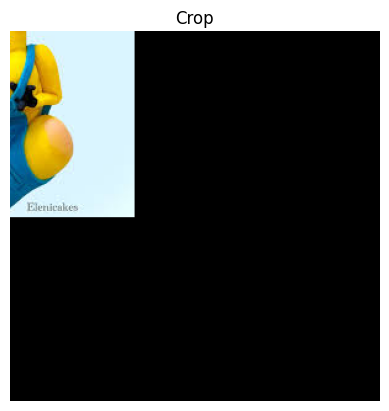

In [10]:
d_crop = cuda.device_array((crop_h, crop_w, 3), dtype=np.uint8)

threads = (16,16)

blocks_crop = (
    math.ceil(crop_h/16),
    math.ceil(crop_w/16)
)

crop_filter[blocks_crop, threads](d_image, d_crop, x_start, y_start)

crop_img = d_crop.copy_to_host()

plt.imshow(crop_img)
plt.title("Crop")
plt.axis("off")

In [11]:
threshold = 128

In [12]:
@cuda.jit
def binary_filter(img, output, threshold):

    row, col = cuda.grid(2)

    if row >= img.shape[0] or col >= img.shape[1]:
        return

    r = img[row,col,0]
    g = img[row,col,1]
    b = img[row,col,2]

    gray = (r + g + b) // 3

    value = 255 if gray > threshold else 0

    output[row,col,0] = value
    output[row,col,1] = value
    output[row,col,2] = value

(np.float64(-0.5), np.float64(200.5), np.float64(250.5), np.float64(-0.5))

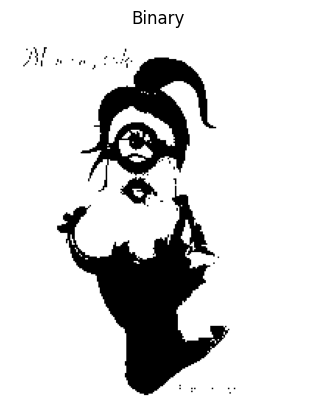

In [13]:
d_binary = cuda.device_array_like(image)

binary_filter[blocks_per_grid, threads_per_block](d_image, d_binary, threshold)

binary_img = d_binary.copy_to_host()

plt.imshow(binary_img)
plt.title("Binary")
plt.axis("off")

(np.float64(-0.5), np.float64(200.5), np.float64(250.5), np.float64(-0.5))

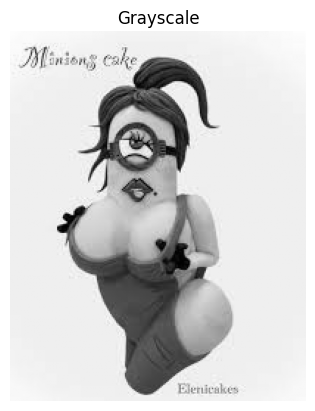

In [14]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

In [15]:
d_gray = cuda.to_device(gray)

d_sobel = cuda.device_array_like(gray)

In [16]:
@cuda.jit
def sobel_filter(gray, output):

    row, col = cuda.grid(2)

    H = gray.shape[0]
    W = gray.shape[1]

    if row >= H or col >= W:
        return

    if row == 0 or row == H-1 or col == 0 or col == W-1:
        output[row,col] = 0
        return

    gx = (
        -1*gray[row-1,col-1] + 1*gray[row-1,col+1] +
        -2*gray[row,col-1]   + 2*gray[row,col+1] +
        -1*gray[row+1,col-1] + 1*gray[row+1,col+1]
    )

    gy = (
        -1*gray[row-1,col-1] + -2*gray[row-1,col] + -1*gray[row-1,col+1] +
         1*gray[row+1,col-1] +  2*gray[row+1,col] +  1*gray[row+1,col+1]
    )

    g = math.sqrt(gx*gx + gy*gy)

    if g > 255:
        g = 255

    output[row,col] = g

(np.float64(-0.5), np.float64(200.5), np.float64(250.5), np.float64(-0.5))

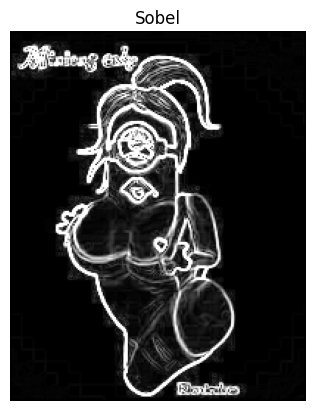

In [17]:
sobel_filter[blocks_per_grid, threads_per_block](d_gray, d_sobel)

sobel_img = d_sobel.copy_to_host()

plt.imshow(sobel_img, cmap='gray')
plt.title("Sobel")
plt.axis("off")

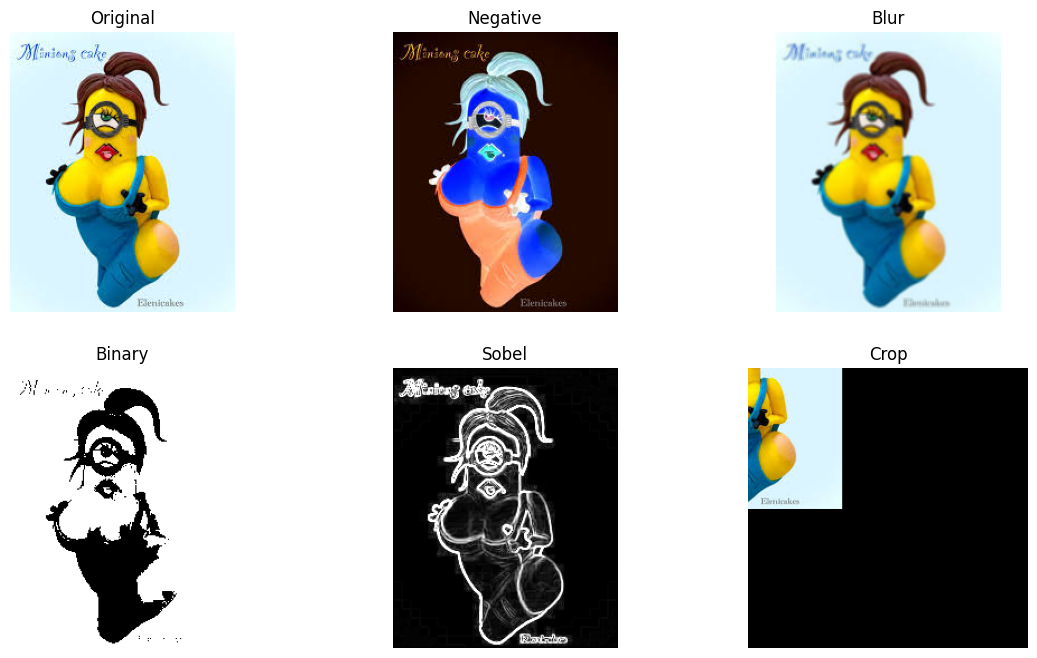

In [18]:
fig, ax = plt.subplots(2,3, figsize=(14,8))

ax[0,0].imshow(image)
ax[0,0].set_title("Original")

ax[0,1].imshow(negative_img)
ax[0,1].set_title("Negative")

ax[0,2].imshow(blur_img)
ax[0,2].set_title("Blur")

ax[1,0].imshow(binary_img)
ax[1,0].set_title("Binary")

ax[1,1].imshow(sobel_img, cmap='gray')
ax[1,1].set_title("Sobel")

ax[1,2].imshow(crop_img)
ax[1,2].set_title("Crop")

for a in ax.flat:
    a.axis("off")

In [19]:
filters_used = [
    "Negative Filter",
    "Blur Filter",
    "Binary Filter",
    "Sobel Filter",
    "Crop Filter"
]

print("Filters Used:")
for filter_name in filters_used:
    print(f"- {filter_name}")

Filters Used:
- Negative Filter
- Blur Filter
- Binary Filter
- Sobel Filter
- Crop Filter
